# 1. Imports

## 1.1. Libraries

In [97]:
!pip install shap



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [98]:
import pandas as pd
import numpy as np
import requests
from sklearn.model_selection import TimeSeriesSplit
from lightgbm import LGBMRegressor
import lightgbm as lgb
from sklearn.metrics import (mean_absolute_error, mean_squared_error)



## 1.2. Loading Data

In [99]:
df_sell_in = pd.read_excel('Business_Case_Data_Set.xlsx', sheet_name='Table 2 - Sell In')
df_external_var = pd.read_excel('Business_Case_Data_Set.xlsx', sheet_name = 'Table 1 - External Variables')
df_data_dic = pd.read_excel('Business_Case_Data_Set.xlsx', sheet_name = 'Table 0 - Data Dictionary')

# 2. Data Description

In [100]:
#Join the dfs:

df = pd.merge(df_external_var, df_sell_in, how='left', on=['Week', 'Product', 'Channel'])
df.head(5)

,Week,Product,Channel,Price_per_kg_USD,Numeric_Distribution,Weighted_Distribution,Advertising_Investment_USD,Promotion_Investment_USD,Promotion_Type,Sell_In_Tons
0,2023-07-03,Natural Juice 1L,Supermarkets,2.47,81.3,86.1,7592,1968,NaN,5.592
1,2023-07-03,Natural Juice 1L,Traditional,2.40,57.2,44.0,2962,1818,Bundle,3.278
2,2023-07-03,Natural Juice 1L,E-commerce,2.58,52.1,61.4,6245,3719,Discount,0.410
3,2023-07-03,Flavored Water 500ml,Supermarkets,1.86,68.4,74.6,7711,1795,Discount,3.531
4,2023-07-03,Flavored Water 500ml,Traditional,1.86,56.2,53.6,3409,2465,Discount,2.134


In [101]:
#Separate the traning and predict df
df_pred = df.loc[df['Sell_In_Tons'].isna()].copy()
df_train = df.loc[~df['Sell_In_Tons'].isna()].copy()

In [102]:
# Verify the sell in df
df_sell_in.head(10)

,Week,Product,Channel,Sell_In_Tons
0,2023-07-03,Natural Juice 1L,Supermarkets,5.592
1,2023-07-03,Natural Juice 1L,Traditional,3.278
2,2023-07-03,Natural Juice 1L,E-commerce,0.410
3,2023-07-03,Flavored Water 500ml,Supermarkets,3.531
4,2023-07-03,Flavored Water 500ml,Traditional,2.134
5,2023-07-03,Flavored Water 500ml,E-commerce,0.250
6,2023-07-03,Energy Drink 350ml,Supermarkets,3.350
7,2023-07-03,Energy Drink 350ml,Traditional,2.952
8,2023-07-03,Energy Drink 350ml,E-commerce,0.555
9,2023-07-03,Whole Grain Crackers 200g,Supermarkets,1.325


* Every line is the Sell In in tons, by week, per product in each Channel

In [103]:
# Verify the External Values df
df_external_var.head(5)

,Week,Product,Channel,Price_per_kg_USD,Numeric_Distribution,Weighted_Distribution,Advertising_Investment_USD,Promotion_Investment_USD,Promotion_Type
0,2023-07-03,Natural Juice 1L,Supermarkets,2.47,81.3,86.1,7592,1968,NaN
1,2023-07-03,Natural Juice 1L,Traditional,2.40,57.2,44.0,2962,1818,Bundle
2,2023-07-03,Natural Juice 1L,E-commerce,2.58,52.1,61.4,6245,3719,Discount
3,2023-07-03,Flavored Water 500ml,Supermarkets,1.86,68.4,74.6,7711,1795,Discount
4,2023-07-03,Flavored Water 500ml,Traditional,1.86,56.2,53.6,3409,2465,Discount


In [104]:
# Check the Variables definition and type:
df_data_dic

,Table,Column,Description,Data_Type
0,Table 1,Week,Week start date (Monday),Date
1,Table 1,Product,Product name,String
2,Table 1,Channel,Sales channel,String
3,Table 1,Price_per_kg_USD,Price per kilogram in USD,Float
4,Table 1,Numeric_Distribution,Numeric distribution (%),Float
5,Table 1,Weighted_Distribution,Weighted distribution (%),Float
6,Table 1,Advertising_Investment_USD,Advertising investment in USD,Float
7,Table 1,Promotion_Investment_USD,Promotion investment in USD,Float
8,Table 1,Promotion_Type,"Type of promotion (None, Discount, BOGO, Bundle)",String
9,Table 2,Week,Week start date (Monday),Date


In [105]:
print('Number of Rows of External Variables df: {}'.format(df_external_var.shape[0]))
print('Number of Cols of External Variables df: {}'.format(df_external_var.shape[1]))

Number of Rows of External Variables df: 3510
Number of Cols of External Variables df: 9


In [106]:
# Columns types information:
df_external_var.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3510 entries, 0 to 3509
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Week                        3510 non-null   object 
 1   Product                     3510 non-null   object 
 2   Channel                     3510 non-null   object 
 3   Price_per_kg_USD            3510 non-null   float64
 4   Numeric_Distribution        3510 non-null   float64
 5   Weighted_Distribution       3510 non-null   float64
 6   Advertising_Investment_USD  3510 non-null   int64  
 7   Promotion_Investment_USD    3510 non-null   int64  
 8   Promotion_Type              1910 non-null   object 
dtypes: float64(3), int64(2), object(4)
memory usage: 246.9+ KB


## 1.1. Sell In/Train Description

In [107]:
print('Number of Rows of Sell In df: {}'.format(df_sell_in.shape[0]))
print('Number of Cols of Sell In df: {}'.format(df_sell_in.shape[1]))

Number of Rows of Sell In df: 2340
Number of Cols of Sell In df: 4


In [108]:
print('Number of Rows of train df: {}'.format(df_train.shape[0]))
print('Number of Cols of train df: {}'.format(df_train.shape[1]))

Number of Rows of train df: 2340
Number of Cols of train df: 10


In [109]:
# Columns types information:
df_sell_in.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2340 entries, 0 to 2339
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Week          2340 non-null   object 
 1   Product       2340 non-null   object 
 2   Channel       2340 non-null   object 
 3   Sell_In_Tons  2340 non-null   float64
dtypes: float64(1), object(3)
memory usage: 73.3+ KB


* The date period is in the following format: YYYY-MM-DD, and represents the first day of the week (monday)

In [110]:
#Transform Week in Date Time
df_sell_in['Week'] = pd.to_datetime(df_sell_in['Week'])
df_external_var['Week'] = pd.to_datetime(df_external_var['Week'])
df_train['Week'] = pd.to_datetime(df_train['Week'])
df_pred['Week'] = pd.to_datetime(df_pred['Week'])

In [111]:
df_sell_in.head(5)

,Week,Product,Channel,Sell_In_Tons
0,2023-07-03,Natural Juice 1L,Supermarkets,5.592
1,2023-07-03,Natural Juice 1L,Traditional,3.278
2,2023-07-03,Natural Juice 1L,E-commerce,0.410
3,2023-07-03,Flavored Water 500ml,Supermarkets,3.531
4,2023-07-03,Flavored Water 500ml,Traditional,2.134


In [112]:
week_count = df_sell_in['Week'].nunique()
week_first = df_sell_in['Week'].min()
week_last = df_sell_in['Week'].max()
week_diff =  ((week_last.year - week_first.year) * 12 + (week_last.month - week_first.month))

print(f'The historic data starts in {week_first} and ends in {week_last}, with a total of {week_count} weeks and {week_diff} months.')

The historic data starts in 2023-07-03 00:00:00 and ends in 2026-06-22 00:00:00, with a total of 156 weeks and 35 months.


In [113]:
#Check NA
df_sell_in.isna().sum()

Week            0
Product         0
Channel         0
Sell_In_Tons    0
dtype: int64

In [114]:
#Check NA
df_train.isna().sum()

Week                             0
Product                          0
Channel                          0
Price_per_kg_USD                 0
Numeric_Distribution             0
Weighted_Distribution            0
Advertising_Investment_USD       0
Promotion_Investment_USD         0
Promotion_Type                1047
Sell_In_Tons                     0
dtype: int64

In [115]:
#Check NA
df_external_var.isna().sum()

Week                             0
Product                          0
Channel                          0
Price_per_kg_USD                 0
Numeric_Distribution             0
Weighted_Distribution            0
Advertising_Investment_USD       0
Promotion_Investment_USD         0
Promotion_Type                1600
dtype: int64

## 1.2. Pred df Description

In [116]:
week_count = df_external_var['Week'].nunique()
week_first = df_external_var['Week'].min()
week_last = df_external_var['Week'].max()
week_diff =  ((week_last.year - week_first.year) * 12 + (week_last.month - week_first.month))

print(f'The historic data starts in {week_first} and ends in {week_last}, with a total of {week_count} weeks and {week_diff} months.')

The historic data starts in 2023-07-03 00:00:00 and ends in 2027-12-20 00:00:00, with a total of 234 weeks and 53 months.


In [117]:
week_count = df_pred['Week'].nunique()
week_first = df_pred['Week'].min()
week_last = df_pred['Week'].max()
week_diff =  ((week_last.year - week_first.year) * 12 + (week_last.month - week_first.month))

print(f'The historic data starts in {week_first} and ends in {week_last}, with a total of {week_count} weeks and {week_diff} months.')

The historic data starts in 2026-06-29 00:00:00 and ends in 2027-12-20 00:00:00, with a total of 78 weeks and 18 months.


## 2.1. Fill Na

In [118]:
df.isna().sum()

Week                             0
Product                          0
Channel                          0
Price_per_kg_USD                 0
Numeric_Distribution             0
Weighted_Distribution            0
Advertising_Investment_USD       0
Promotion_Investment_USD         0
Promotion_Type                1600
Sell_In_Tons                  1170
dtype: int64

In [119]:
df_train['Promotion_Type'] = df_train['Promotion_Type'].fillna('unidentified')
df_pred['Promotion_Type'] = df_pred['Promotion_Type'].fillna('unidentified')

# 5. Data Transformation

In [120]:
df_train['Promotion_Type'].unique()

array(['unidentified', 'Bundle', 'Discount', 'BOGO'], dtype=object)

In [121]:
# Promotion_Type encoding
encoding = {
    'unidentified':0,
    'Discount':1,
    'BOGO':2,
    'Bundle':3
}

df_train['Promotion_Type'] = df_train['Promotion_Type'].map(encoding)

## 5.2. Deal with duplicates

In [122]:
df_train[df_train[['Week', 'Product', 'Channel']].duplicated(keep=False)]

,Week,Product,Channel,Price_per_kg_USD,Numeric_Distribution,Weighted_Distribution,Advertising_Investment_USD,Promotion_Investment_USD,Promotion_Type,Sell_In_Tons


In [123]:
df_train = df_train.drop_duplicates(subset=['Week', 'Product', 'Channel']).reset_index(drop=True)

# 4. Features Engineering

* **Lag_1w:** Sell-In volume lagged by 1 week
* **Lag_4w:**	Sell-In volume lagged by 4 weeks
* **Rolling_Mean_4w:** Rolling mean of Sell-In over last 4 weeks
* **Rolling_Std_4w:**	Rolling standard deviation of Sell-In over last 4 weeks
* **Price_Change_Pct:** Week-over-week percentage change in Price per kg
* **Promo_Flag:**	Binary flag: 1 if Promotion_Type != None, else 0
* **Month_Sin:** Sine transformation of month number (cyclical encoding)
* **Month_Cos:** Cosine transformation of month number (cyclical encoding)
* **Holiday_Flag:** Binary flag: 1 if week contains a national holiday, else 0
* **Interaction_Price_Promo:** Interaction term: Price_per_kg_USD * Promo_Flag (captures joint effect of price and promotion)


In [124]:
# Lag_1w and Lag_4w
df_train = df_train.sort_values(["Channel", "Product", "Week"]).reset_index(drop=True)

df_train["Lag_1w"] = (df_train.groupby(["Channel", "Product"])["Sell_In_Tons"].shift(1))
df_train["Lag_2w"] = (df_train.groupby(["Channel", "Product"])["Sell_In_Tons"].shift(2))
df_train["Lag_3w"] = (df_train.groupby(["Channel", "Product"])["Sell_In_Tons"].shift(3))
df_train["Lag_4w"] = (df_train.groupby(["Channel", "Product"])["Sell_In_Tons"].shift(4))


df_pred = df_pred.sort_values(["Channel", "Product", "Week"]).reset_index(drop=True)

df_pred["Lag_1w"] = (df_pred.groupby(["Channel", "Product"])["Sell_In_Tons"].shift(1))
df_pred["Lag_2w"] = (df_pred.groupby(["Channel", "Product"])["Sell_In_Tons"].shift(2))
df_pred["Lag_3w"] = (df_pred.groupby(["Channel", "Product"])["Sell_In_Tons"].shift(3))
df_pred["Lag_4w"] = (df_pred.groupby(["Channel", "Product"])["Sell_In_Tons"].shift(4))

In [125]:
# Rolling_Mean_4w

df_train['Rolling_Mean_4w'] = df_train[['Lag_1w', 'Lag_2w', 'Lag_3w', 'Lag_4w']].mean(axis=1)

In [126]:
# Rolling_Std_4w

df_train['Rolling_Std_4w'] = df_train[['Lag_1w', 'Lag_2w', 'Lag_3w', 'Lag_4w']].std(axis=1)

In [127]:
# Price_Change_Pct
df_train = df_train.sort_values(["Channel", "Product", "Week"])

df_train["Price_Change_Pct"] = (df_train.groupby(["Channel", "Product"])["Price_per_kg_USD"].pct_change())

In [128]:
# Promo_Flag
df_train['Promo_Flag'] = np.where(df_train['Promotion_Type'] != 0, 1, 0)

In [129]:
# Month_Sin and Month_Cos
df_train["Month"] = df_train["Week"].dt.month
df_train["Month_Sin"] = np.sin(2*np.pi*df_train["Month"]/12)
df_train["Month_cos"] = np.cos(2*np.pi*df_train["Month"]/12)

In [130]:
# Holiday_Flag


In [131]:
# CREATE DF WITH HOLLIDAYS IN ECUADOR
years = range(2023, 2027)
country = "EC"

all_holidays = []

for year in years:
    url = f"https://date.nager.at/api/v3/PublicHolidays/{year}/{country}"
    response = requests.get(url)
    response.raise_for_status()

    data = response.json()  # lista de dicionários

    for item in data:
        item["year"] = year
        all_holidays.append(item)

df_holidays = pd.DataFrame(all_holidays)
df_holidays["date"] = pd.to_datetime(df_holidays["date"])

In [132]:
#CREATE DICTIONARY OF WEEK
df_calendar = pd.DataFrame({
    "Date": pd.date_range(
        start="2023-07-03",
        end="2027-12-20",
        freq="D"
    )
})

df_calendar["Week_Number"] = (
    ((df_calendar["Date"] - pd.Timestamp("2023-07-03")).dt.days // 7) + 1
)

df_calendar["Week_Start"] = (
    pd.Timestamp("2023-07-03") +
    pd.to_timedelta((df_calendar["Week_Number"] - 1) * 7, unit="D")
)

df_calendar["Day_Name"] = df_calendar["Date"].dt.day_name()

In [133]:
#Identify the week number in both dfs (holidays and train)
df_train = df_train.merge(df_calendar[['Date', 'Week_Number']], how='left', left_on='Week', right_on='Date').drop(columns='Date')
df_holidays = df_holidays.merge(df_calendar[['Date', 'Week_Number']], how='left', left_on='date', right_on='Date').drop(columns='Date')
df_holidays['Week_Number'] = df_holidays['Week_Number'].astype("Int64")
df_holidays['Holiday'] = 1


In [134]:
df_holidays = (df_holidays.groupby("Week_Number", as_index=False)["Holiday"].max())

In [135]:
#Identify the holiday weeks in the df_train

df_train = df_train.merge(df_holidays[['Week_Number', 'Holiday']], how='left', on='Week_Number')
df_train['Holiday'] = df_train['Holiday'].fillna(0).astype("Int64")
df_train.rename(columns={"Holiday": "Holiday_Flag"}, inplace=True)

In [136]:
df_pred = df_pred.merge(df_calendar[['Date', 'Week_Number']], how='left', left_on='Week', right_on='Date').drop(columns='Date')


In [137]:
#Interaction_Price_Promo
df_train['Interaction_Price_Promo'] = df_train['Price_per_kg_USD'] * df_train['Promo_Flag']

# 5. Exploratory Data Analysis

* Quanto foi vendido por produto e channel ao longo do tempo ? (Gráfico de linhas)
* 

# 6. Product/Channel Filter

In [138]:
keys = (df_train[['Product', 'Channel']]).drop_duplicates().reset_index(drop=True)
keys

,Product,Channel
0,Cereal Bar 50g,E-commerce
1,Energy Drink 350ml,E-commerce
2,Flavored Water 500ml,E-commerce
3,Natural Juice 1L,E-commerce
4,Whole Grain Crackers 200g,E-commerce
5,Cereal Bar 50g,Supermarkets
6,Energy Drink 350ml,Supermarkets
7,Flavored Water 500ml,Supermarkets
8,Natural Juice 1L,Supermarkets
9,Whole Grain Crackers 200g,Supermarkets


In [139]:
#df_train2 = df_train.copy()

In [140]:
#df_train = df_train2[(df_train2['Product'] == 'Cereal Bar 50g') & (df_train2['Channel'] == 'Traditional')]
#df_train = df_train.reset_index(drop=True)

# 7. Features Selection

In [141]:
df_train.columns

Index(['Week', 'Product', 'Channel', 'Price_per_kg_USD',
       'Numeric_Distribution', 'Weighted_Distribution',
       'Advertising_Investment_USD', 'Promotion_Investment_USD',
       'Promotion_Type', 'Sell_In_Tons', 'Lag_1w', 'Lag_2w', 'Lag_3w',
       'Lag_4w', 'Rolling_Mean_4w', 'Rolling_Std_4w', 'Price_Change_Pct',
       'Promo_Flag', 'Month', 'Month_Sin', 'Month_cos', 'Week_Number',
       'Holiday_Flag', 'Interaction_Price_Promo'],
      dtype='object')

In [142]:
df_train = df_train.drop(columns=['Lag_1w','Lag_2w', 'Lag_3w','Lag_4w', 'Month', 'Week_Number', 'Rolling_Std_4w', 'Rolling_Mean_4w'])

# 8. Machine Learnin Modeling 

* I decided using the method of the rolling backtest, using 52 weeks (1 year) as window, i.e. a whole year.

# 9. Hyperparameter Fine Tuning

In [143]:
"""
Validação recursiva (walk-forward) para forecasting de SI com LightGBM,
rodada individualmente para cada combinação de Product x Channel.

Contexto:
- Histórico total: 156 semanas (por combinação)
- Horizonte real de previsão: 78 semanas
- Features dependentes do target (vazam informação se calculadas sobre a série toda):
    - LAG1, LAG4
    - média móvel das últimas 4 semanas
    - desvio-padrão móvel das últimas 4 semanas

Estratégia:
1. Para cada combinação de Product/Channel, split temporal: treino = primeiras
   (N - HORIZON) semanas, validação = últimas HORIZON semanas.
2. No treino, os lags/rolling são calculados normalmente (tudo é passado real).
3. Na validação, a previsão é feita semana a semana: os lags/rolling de cada passo usam
   o histórico real (enquanto ainda dentro do período de treino) + as PREVISÕES do próprio
   modelo (para os passos já "previstos" dentro da validação) — nunca o SI real da validação.
   Isso replica fielmente o que vai acontecer em produção.
4. Ao final, as métricas de cada combinação são consolidadas em uma tabela-resumo.

Ajuste os nomes de colunas (DATE_COL, TARGET, GROUP_COLS) e os hiperparâmetros do LGBM
conforme o seu caso.
"""

import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    # Se for usar o método "optuna", rode antes: pip install optuna

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    # Se for usar as funções de SHAP, rode antes: pip install shap

# ---------------------------------------------------------
# CONFIGURAÇÕES — ajuste conforme seu projeto
# ---------------------------------------------------------
TARGET = "Sell_In_Tons"
DATE_COL = "Week"           # coluna de data em df_train (datetime)
GROUP_COLS = ["Product", "Channel"]   # colunas que identificam cada série/combinação
HORIZON = 78                 # semanas a validar (igual ao horizonte real de previsão)
LAGS = [1, 4]
ROLL_WINDOW = 4

# Hiperparâmetros default / ponto de partida (serão substituídos pelo tuning por combinação)
LGBM_PARAMS = {
    "n_estimators": 500,
    "learning_rate": 0.1,
    "max_depth": 12,
    "num_leaves": 256,
    "min_child_samples": 5,
    "subsample": 0.7,
    "subsample_freq": 1,   # necessário para o "subsample" do LightGBM ter efeito
    "colsample_bytree": 0.7,
    "reg_alpha": 0.0,
    "reg_lambda": 0.0,
    "min_split_gain": 0.0,
    "boosting_type": "gbdt",
    "objective": "regression",
    "metric": "mape",
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1,
}

# Parâmetros fixos (não entram na busca, mas são aplicados junto do resultado)
FIXED_PARAMS = {
    "subsample_freq": 1,
    "boosting_type": "gbdt",
    "objective": "regression",
    "metric": "mape",
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1,
}


# ---------------------------------------------------------
# 1. Função para criar as features dependentes do target
#    (mesma lógica usada no treino e, passo a passo, na validação)
# ---------------------------------------------------------
def add_target_features(df, target_col=TARGET, lags=LAGS, window=ROLL_WINDOW):
    df = df.copy()
    for l in lags:
        df[f"{target_col}_lag{l}"] = df[target_col].shift(l)
    df[f"{target_col}_roll_mean{window}"] = df[target_col].shift(1).rolling(window).mean()
    df[f"{target_col}_roll_std{window}"] = df[target_col].shift(1).rolling(window).std(ddof=1)
    return df


# ---------------------------------------------------------
# 2. Validação recursiva para UMA combinação (uma série já filtrada)
# ---------------------------------------------------------
def run_validation(df_sub, group_cols=GROUP_COLS, params=None, verbose=True):
    params = params or LGBM_PARAMS
    df_sub = df_sub.sort_values(DATE_COL).reset_index(drop=True)

    # exclui data, target e as colunas identificadoras (Product/Channel) das features,
    # já que dentro de cada combinação elas são constantes
    excluded_cols = [DATE_COL, TARGET] + [c for c in group_cols if c in df_sub.columns]
    feature_cols_base = [c for c in df_sub.columns if c not in excluded_cols]
    target_feature_cols = (
        [f"{TARGET}_lag{l}" for l in LAGS]
        + [f"{TARGET}_roll_mean{ROLL_WINDOW}", f"{TARGET}_roll_std{ROLL_WINDOW}"]
    )
    feature_cols = feature_cols_base + target_feature_cols

    # -----------------------------------------------------
    # Split temporal
    # -----------------------------------------------------
    n_total = len(df_sub)
    n_train = n_total - HORIZON
    if n_train <= max(LAGS + [ROLL_WINDOW]):
        raise ValueError(
            f"Histórico insuficiente para essa combinação "
            f"(n_total={n_total}, necessário > {HORIZON + max(LAGS + [ROLL_WINDOW])})."
        )

    df_hist = df_sub.iloc[:n_train].copy()
    df_valid = df_sub.iloc[n_train:].reset_index(drop=True).copy()

    if verbose:
        print(f"Treino: {len(df_hist)} semanas | Validação: {len(df_valid)} semanas")

    # -----------------------------------------------------
    # Dataset de treino (lags/rolling calculados com dados reais)
    # -----------------------------------------------------
    df_hist_feat = add_target_features(df_hist).dropna().reset_index(drop=True)

    X_train = df_hist_feat[feature_cols]
    y_train = df_hist_feat[TARGET]

    # -----------------------------------------------------
    # Treinamento do modelo
    # -----------------------------------------------------
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train)

    # -----------------------------------------------------
    # Validação recursiva (walk-forward)
    # -----------------------------------------------------
    history = df_hist[TARGET].tolist()  # série real conhecida até o início da validação
    preds = []

    for i in range(len(df_valid)):
        row = df_valid.loc[[i]].copy()

        lag1 = history[-1]
        lag4 = history[-4]
        roll_mean = np.mean(history[-ROLL_WINDOW:])
        roll_std = np.std(history[-ROLL_WINDOW:], ddof=1)

        row[f"{TARGET}_lag1"] = lag1
        row[f"{TARGET}_lag4"] = lag4
        row[f"{TARGET}_roll_mean{ROLL_WINDOW}"] = roll_mean
        row[f"{TARGET}_roll_std{ROLL_WINDOW}"] = roll_std

        X_step = row[feature_cols]
        y_hat = model.predict(X_step)[0]

        preds.append(y_hat)
        history.append(y_hat)  # usa a PREVISÃO, não o valor real -> simula produção

    # -----------------------------------------------------
    # Avaliação
    # -----------------------------------------------------
    y_true = df_valid[TARGET].values
    y_pred = np.array(preds)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAPE — atenção: indefinido/instável se y_true tiver valores 0 ou muito próximos de 0.
    # Se o seu SI puder ter zeros, considere usar WMAPE como complemento (mais robusto).
    mape = np.mean(np.abs((y_true - y_pred) / y_true))
    wmape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

    if verbose:
        print(f"MAPE:  {mape:.2%}")
        print(f"WMAPE: {wmape:.2%}")
        print(f"MAE:   {mae:.3f}")
        print(f"RMSE:  {rmse:.3f}")

    df_result = df_valid[[DATE_COL, TARGET]].copy()
    df_result["pred"] = y_pred
    df_result["abs_pct_error"] = np.abs((df_result[TARGET] - df_result["pred"]) / df_result[TARGET])

    return model, df_result, {"mape": mape, "wmape": wmape, "mae": mae, "rmse": rmse}


# ---------------------------------------------------------
# 2.5. Tuning de hiperparâmetros para UMA combinação (Optuna)
# ---------------------------------------------------------
def tune_hyperparameters_optuna(df_sub, group_cols=GROUP_COLS, n_trials=50, cv_splits=3, verbose=False):
    """
    Busca bayesiana de hiperparâmetros com Optuna (TPESampler), usando SOMENTE o
    período de treino (as primeiras n_total - HORIZON semanas) — as últimas HORIZON
    semanas ficam de fora e são usadas depois, intocadas, na validação recursiva
    final (run_validation).

    A validação cruzada respeita a ordem temporal (TimeSeriesSplit): cada fold treina
    com um bloco de semanas passadas e valida no bloco seguinte, nunca embaralhando.

    O Optuna usa o resultado das tentativas anteriores para direcionar a busca para
    regiões mais promissoras do espaço de hiperparâmetros, em vez de sortear
    aleatoriamente — geralmente encontra combinações melhores com o mesmo orçamento
    de tentativas que um Randomized/Grid Search.

    Observação: essa busca usa previsão "um passo à frente" (não recursiva) por questão
    de custo computacional — é a abordagem padrão para tuning. A avaliação final honesta
    (com erro acumulado do processo recursivo) continua sendo feita por run_validation.

    Requer: pip install optuna
    """
    if not OPTUNA_AVAILABLE:
        raise ImportError("Optuna não está instalado. Rode: pip install optuna")

    df_sub = df_sub.sort_values(DATE_COL).reset_index(drop=True)

    excluded_cols = [DATE_COL, TARGET] + [c for c in group_cols if c in df_sub.columns]
    feature_cols_base = [c for c in df_sub.columns if c not in excluded_cols]
    target_feature_cols = (
        [f"{TARGET}_lag{l}" for l in LAGS]
        + [f"{TARGET}_roll_mean{ROLL_WINDOW}", f"{TARGET}_roll_std{ROLL_WINDOW}"]
    )
    feature_cols = feature_cols_base + target_feature_cols

    n_total = len(df_sub)
    n_train = n_total - HORIZON
    if n_train <= max(LAGS + [ROLL_WINDOW]) + cv_splits:
        raise ValueError(
            f"Histórico insuficiente para tuning com {cv_splits} folds (n_total={n_total})."
        )

    df_hist = df_sub.iloc[:n_train].copy()
    df_hist_feat = add_target_features(df_hist).dropna().reset_index(drop=True)

    X = df_hist_feat[feature_cols]
    y = df_hist_feat[TARGET]

    tscv = TimeSeriesSplit(n_splits=cv_splits)
    splits = list(tscv.split(X))  # calcula uma vez só, reutiliza em todos os trials

    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 200, 1200, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 14),
            "num_leaves": trial.suggest_int("num_leaves", 15, 300),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 60),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 0.5),
            **FIXED_PARAMS,
        }

        fold_mapes = []
        for train_idx, val_idx in splits:
            X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

            model = lgb.LGBMRegressor(**params)
            model.fit(X_tr, y_tr)
            preds = model.predict(X_val)

            fold_mape = np.mean(np.abs((y_val.values - preds) / y_val.values))
            fold_mapes.append(fold_mape)

        return np.mean(fold_mapes)

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=verbose)

    best_params = {**FIXED_PARAMS, **study.best_params}
    return best_params, study.best_value


# ---------------------------------------------------------
# 3. Loop por todas as combinações: tuning + validação recursiva final
# ---------------------------------------------------------
def run_tuning_and_validation_all(
    df_train, group_cols=GROUP_COLS, n_trials=50, cv_splits=3, verbose=False
):
    """
    Para cada combinação de group_cols:
      1. Faz a busca bayesiana de hiperparâmetros (Optuna) apenas no período de treino.
      2. Roda a validação recursiva final (78 semanas) com os melhores parâmetros.

    Retorna:
        df_summary: uma linha por combinação, com o MAPE final (recursivo) e os melhores
                     hiperparâmetros encontrados.
        detailed_results: dict {combinação: {"model", "df_result", "best_params"}}
    """
    combinations = df_train[group_cols].drop_duplicates().reset_index(drop=True)

    summary_rows = []
    detailed_results = {}

    for idx, combo in combinations.iterrows():
        filtro = np.all([df_train[col] == combo[col] for col in group_cols], axis=0)
        df_sub = df_train[filtro].copy()

        combo_key = tuple(combo[col] for col in group_cols)
        combo_label = " | ".join(f"{col}={combo[col]}" for col in group_cols)

        print(f"\n=== Tuning (Optuna) + validação: {combo_label} ===")

        row = {col: combo[col] for col in group_cols}

        try:
            best_params, cv_mape = tune_hyperparameters_optuna(
                df_sub, group_cols=group_cols, n_trials=n_trials, cv_splits=cv_splits, verbose=verbose
            )
            print(f"Melhor MAPE (CV, um passo à frente): {cv_mape:.2%}")

            model, df_result, metrics = run_validation(
                df_sub, group_cols=group_cols, params=best_params, verbose=verbose
            )

            row.update(metrics)
            row["cv_mape"] = cv_mape
            row["n_semanas"] = len(df_sub)
            row["status"] = "ok"
            row["best_params"] = best_params
            detailed_results[combo_key] = {
                "model": model, "df_result": df_result, "best_params": best_params
            }
            print(f"MAPE final (validação recursiva, {HORIZON} semanas): {metrics['mape']:.2%}")

        except Exception as e:
            row.update({"mape": np.nan, "wmape": np.nan, "mae": np.nan, "rmse": np.nan, "cv_mape": np.nan})
            row["n_semanas"] = len(df_sub)
            row["status"] = f"erro: {e}"
            row["best_params"] = None
            print(f"[ERRO] {combo_label} -> {e}")

        summary_rows.append(row)

    df_summary = pd.DataFrame(summary_rows)
    df_summary = df_summary.sort_values("mape", ascending=False, na_position="last").reset_index(drop=True)

    return df_summary, detailed_results


# ---------------------------------------------------------
# 3b. Loop por todas as combinações usando hiperparâmetros fixos (sem tuning)
# ---------------------------------------------------------
def run_validation_all(df_train, group_cols=GROUP_COLS, params=None, verbose=False):
    """
    Roda run_validation individualmente para cada combinação de group_cols
    (ex: Product x Channel) e consolida os resultados em uma tabela-resumo.

    Retorna:
        df_summary: DataFrame com uma linha por combinação e as métricas (MAPE, WMAPE, MAE, RMSE)
        detailed_results: dict {combinação: {"model":..., "df_result":...}} para inspeção posterior
    """
    combinations = df_train[group_cols].drop_duplicates().reset_index(drop=True)

    summary_rows = []
    detailed_results = {}

    for idx, combo in combinations.iterrows():
        filtro = np.all(
            [df_train[col] == combo[col] for col in group_cols], axis=0
        )
        df_sub = df_train[filtro].copy()

        combo_key = tuple(combo[col] for col in group_cols)
        combo_label = " | ".join(f"{col}={combo[col]}" for col in group_cols)

        print(f"\n=== Validando: {combo_label} ===")

        row = {col: combo[col] for col in group_cols}

        try:
            model, df_result, metrics = run_validation(df_sub, group_cols=group_cols, params=params, verbose=verbose)
            row.update(metrics)
            row["n_semanas"] = len(df_sub)
            row["status"] = "ok"
            detailed_results[combo_key] = {"model": model, "df_result": df_result}
            print(f"MAPE: {metrics['mape']:.2%}")
        except Exception as e:
            row.update({"mape": np.nan, "wmape": np.nan, "mae": np.nan, "rmse": np.nan})
            row["n_semanas"] = len(df_sub)
            row["status"] = f"erro: {e}"
            print(f"[ERRO] {combo_label} -> {e}")

        summary_rows.append(row)

    df_summary = pd.DataFrame(summary_rows)
    df_summary = df_summary.sort_values("mape", ascending=False, na_position="last").reset_index(drop=True)

    return df_summary, detailed_results


def plot_validation_results(df_result, title_suffix="", target_col=TARGET, date_col=DATE_COL):
    """
    Gera dois gráficos para uma combinação específica:
      1. Real vs. Previsto ao longo das semanas de validação.
      2. Erro percentual absoluto (%) por semana, para identificar onde o modelo
         degrada mais (ex: acúmulo de erro recursivo nas semanas finais do horizonte).
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    axes[0].plot(df_result[date_col], df_result[target_col], label="Real", marker="o", markersize=3)
    axes[0].plot(df_result[date_col], df_result["pred"], label="Previsto", marker="o", markersize=3)
    axes[0].set_title(f"SI: Real vs. Previsto {title_suffix}")
    axes[0].set_ylabel("SI")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    erro_pct = df_result["abs_pct_error"] * 100
    axes[1].bar(df_result[date_col], erro_pct, color="indianred", alpha=0.7)
    axes[1].axhline(erro_pct.mean(), color="black", linestyle="--", linewidth=1,
                     label=f"MAPE médio: {erro_pct.mean():.1f}%")
    axes[1].set_title("Erro percentual absoluto por semana")
    axes[1].set_ylabel("Erro (%)")
    axes[1].set_xlabel(date_col)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return fig


def build_training_features(df_sub, group_cols=GROUP_COLS):
    """
    Reconstrói exatamente o X_train/y_train usados no treino de run_validation
    para uma combinação — necessário para o SHAP explicar o modelo com os
    mesmos dados que ele efetivamente aprendeu.
    """
    df_sub = df_sub.sort_values(DATE_COL).reset_index(drop=True)

    excluded_cols = [DATE_COL, TARGET] + [c for c in group_cols if c in df_sub.columns]
    feature_cols_base = [c for c in df_sub.columns if c not in excluded_cols]
    target_feature_cols = (
        [f"{TARGET}_lag{l}" for l in LAGS]
        + [f"{TARGET}_roll_mean{ROLL_WINDOW}", f"{TARGET}_roll_std{ROLL_WINDOW}"]
    )
    feature_cols = feature_cols_base + target_feature_cols

    n_total = len(df_sub)
    n_train = n_total - HORIZON
    df_hist = df_sub.iloc[:n_train].copy()
    df_hist_feat = add_target_features(df_hist).dropna().reset_index(drop=True)

    X_train = df_hist_feat[feature_cols]
    y_train = df_hist_feat[TARGET]

    return X_train, y_train, feature_cols


def plot_shap_summary(model, df_sub, group_cols=GROUP_COLS, max_display=15, plot_type="dot"):
    """
    Gera o SHAP summary plot: mostra quais features mais influenciam as previsões
    do modelo e em que direção (valores altos/baixos da feature empurram a previsão
    para cima ou para baixo).

    plot_type="dot"  -> gráfico de pontos (mostra direção do efeito)
    plot_type="bar"  -> gráfico de barras (mostra só a magnitude média, sem direção)

    Requer: pip install shap
    """
    if not SHAP_AVAILABLE:
        raise ImportError("SHAP não está instalado. Rode: pip install shap")

    X_train, _, _ = build_training_features(df_sub, group_cols)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train)

    shap.summary_plot(shap_values, X_train, max_display=max_display, plot_type=plot_type, show=True)

    return explainer, shap_values, X_train


def plot_shap_dependence(model, df_sub, feature_name, group_cols=GROUP_COLS, interaction_feature="auto"):
    """
    Gera o SHAP dependence plot para UMA feature específica: mostra como o valor
    dessa feature se relaciona com o impacto dela na previsão (útil para entender
    ex: "valores altos de roll_mean4 aumentam a previsão de forma linear ou não?").
    """
    if not SHAP_AVAILABLE:
        raise ImportError("SHAP não está instalado. Rode: pip install shap")

    X_train, _, feature_cols = build_training_features(df_sub, group_cols)
    if feature_name not in feature_cols:
        raise ValueError(f"'{feature_name}' não está entre as features do modelo: {feature_cols}")

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train)

    shap.dependence_plot(feature_name, shap_values, X_train, interaction_index=interaction_feature, show=True)


def plot_shap_waterfall(model, df_sub, group_cols=GROUP_COLS, row_index=0, from_validation=False):
    """
    Explica UMA previsão específica: mostra como cada feature empurrou a previsão
    para cima ou para baixo, partindo do valor base (média do modelo).

    from_validation=False -> explica uma linha do período de TREINO (row_index é a
                              posição dentro de X_train)
    from_validation=True  -> explica uma linha do período de VALIDAÇÃO (útil para
                              entender por que o modelo errou uma semana específica,
                              ex: um dos picos discutidos anteriormente). Nesse caso,
                              os lags/rolling usados são os mesmos calculados durante
                              a validação recursiva (reais até o ponto de corte, depois
                              baseados nas previsões do próprio modelo).
    """
    if not SHAP_AVAILABLE:
        raise ImportError("SHAP não está instalado. Rode: pip install shap")

    if not from_validation:
        X, _, _ = build_training_features(df_sub, group_cols)
    else:
        # Reaproveita run_validation para obter exatamente os X_step usados na validação
        raise NotImplementedError(
            "Para explicar uma semana da validação, gere X_step manualmente (mesma lógica "
            "do loop recursivo em run_validation) e chame shap.Explainer nele. Avise se quiser "
            "que eu implemente essa variante junto com o retorno de df_result."
        )

    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X)

    shap.plots.waterfall(shap_values[row_index], show=True)



# ---------------------------------------------------------
# EXECUÇÃO
# ---------------------------------------------------------
# Assume que df_train já existe no ambiente, contendo Product, Channel,
# Week, Sell_In_Tons e demais features exógenas.

# n_trials = quantas tentativas o Optuna faz por combinação de Product/Channel
# cv_splits = quantos folds temporais usar dentro do período de treino
df_summary, detailed_results = run_tuning_and_validation_all(
    df_train, n_trials=50, cv_splits=3, verbose=False
)

print("\n=== Tabela-resumo: MAPE final por combinação (após tuning) ===")
print(df_summary.drop(columns=["best_params"]))

# Exemplo: para inspecionar os hiperparâmetros escolhidos e o gráfico de uma combinação:
# combo_key = ("Produto_X", "Canal_Y")
# print(detailed_results[combo_key]["best_params"])
# plot_validation_results(detailed_results[combo_key]["df_result"], title_suffix=str(combo_key))

# Exemplo: para ver os SHAP values de uma combinação específica (requer pip install shap):
# combo_key = ("Produto_X", "Canal_Y")
# model = detailed_results[combo_key]["model"]
# filtro = np.all([df_train[col] == v for col, v in zip(GROUP_COLS, combo_key)], axis=0)
# df_sub = df_train[filtro].copy()
#
# plot_shap_summary(model, df_sub)                              # visão geral das features
# plot_shap_dependence(model, df_sub, "Sell_In_Tons_lag1")       # detalhe de uma feature
# plot_shap_waterfall(model, df_sub, row_index=0)                # explica uma previsão específica

c:\Users\priip\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== Tuning (Optuna) + validação: Product=Cereal Bar 50g | Channel=E-commerce ===
Melhor MAPE (CV, um passo à frente): 11.16%
MAPE final (validação recursiva, 78 semanas): 12.27%

=== Tuning (Optuna) + validação: Product=Energy Drink 350ml | Channel=E-commerce ===
Melhor MAPE (CV, um passo à frente): 67.62%
MAPE final (validação recursiva, 78 semanas): 120.39%

=== Tuning (Optuna) + validação: Product=Flavored Water 500ml | Channel=E-commerce ===
Melhor MAPE (CV, um passo à frente): 71.48%
MAPE final (validação recursiva, 78 semanas): 93.73%

=== Tuning (Optuna) + validação: Product=Natural Juice 1L | Channel=E-commerce ===
Melhor MAPE (CV, um passo à frente): 97.19%
MAPE final (validação recursiva, 78 semanas): 98.37%

=== Tuning (Optuna) + validação: Product=Whole Grain Crackers 200g | Channel=E-commerce ===
Melhor MAPE (CV, um passo à frente): 14.81%
MAPE final (validação recursiva, 78 semanas): 13.79%

=== Tuning (Optuna) + validação: Product=Cereal Bar 50g | Channel=Supermarkets =

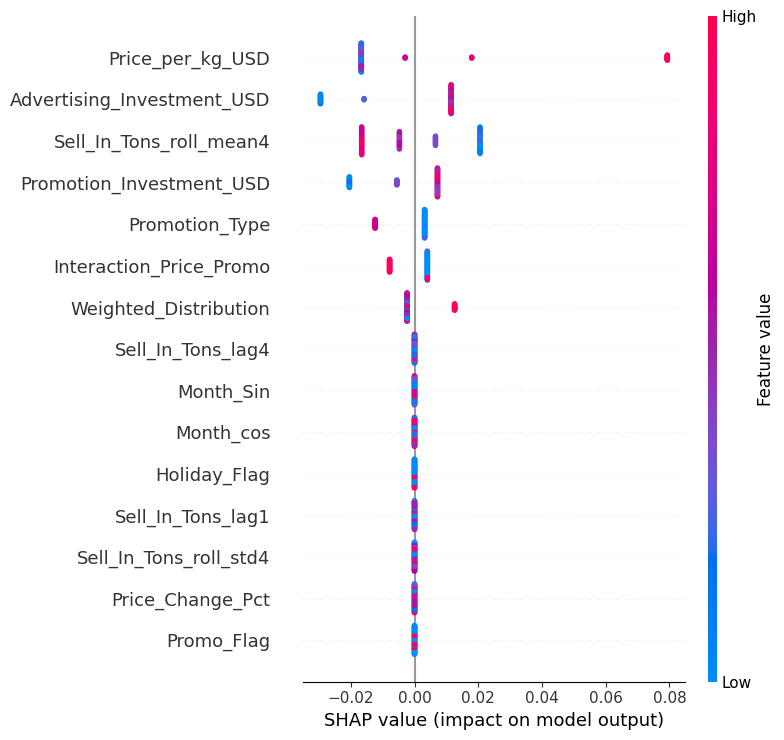

(<shap.explainers._tree.TreeExplainer at 0x231c83c8590>,
 array([[-0.01670269,  0.        , -0.00234089, ...,  0.        ,
          0.00656934,  0.        ],
        [-0.01670269,  0.        , -0.00234089, ...,  0.        ,
         -0.01657374,  0.        ],
        [-0.00293787,  0.        , -0.00234089, ...,  0.        ,
         -0.00473994,  0.        ],
        ...,
        [-0.01670269,  0.        , -0.00234089, ...,  0.        ,
          0.02055231,  0.        ],
        [-0.01670269,  0.        ,  0.01258227, ...,  0.        ,
          0.02055231,  0.        ],
        [-0.01670269,  0.        , -0.00234089, ...,  0.        ,
          0.00656934,  0.        ]], shape=(74, 16)),
     Price_per_kg_USD  Numeric_Distribution  Weighted_Distribution  \
 0              12.03                  64.8                   52.9   
 1              11.82                  52.4                   43.4   
 2              12.29                  58.3                   50.3   
 3              11.9

In [146]:
# Exemplo: para ver os SHAP values de uma combinação específica (requer pip install shap):
combo_key = ("Cereal Bar 50g", "E-commerce")
model = detailed_results[combo_key]["model"]
filtro = np.all([df_train[col] == v for col, v in zip(GROUP_COLS, combo_key)], axis=0)
df_sub = df_train[filtro].copy()

plot_shap_summary(model, df_sub)                              # visão geral das features
#plot_shap_dependence(model, df_sub, "Sell_In_Tons_lag1")       # detalhe de uma feature
#plot_shap_waterfall(model, df_sub, row_index=0)                # explica uma previsão específica

In [144]:
df_summary

,Product,Channel,mape,wmape,mae,rmse,cv_mape,n_semanas,status,best_params
0,Energy Drink 350ml,E-commerce,1.203862,0.542053,0.780528,0.951518,0.676190,156,ok,"{'subsample_freq': 1, 'boosting_type': 'gbdt',..."
1,Natural Juice 1L,E-commerce,0.983748,0.518510,1.141413,1.421957,0.971925,156,ok,"{'subsample_freq': 1, 'boosting_type': 'gbdt',..."
2,Flavored Water 500ml,E-commerce,0.937287,0.498297,0.909296,1.160039,0.714762,156,ok,"{'subsample_freq': 1, 'boosting_type': 'gbdt',..."
3,Whole Grain Crackers 200g,Traditional,0.451662,0.443276,1.084071,1.532439,0.266513,156,ok,"{'subsample_freq': 1, 'boosting_type': 'gbdt',..."
4,Cereal Bar 50g,Traditional,0.317434,0.316695,0.564826,0.877891,0.227761,156,ok,"{'subsample_freq': 1, 'boosting_type': 'gbdt',..."
5,Energy Drink 350ml,Supermarkets,0.297591,0.237112,1.035154,1.302723,0.279537,156,ok,"{'subsample_freq': 1, 'boosting_type': 'gbdt',..."
6,Flavored Water 500ml,Supermarkets,0.277316,0.243029,1.271922,1.582378,0.314432,156,ok,"{'subsample_freq': 1, 'boosting_type': 'gbdt',..."
7,Whole Grain Crackers 200g,Supermarkets,0.265851,0.225425,0.660857,0.806799,0.201210,156,ok,"{'subsample_freq': 1, 'boosting_type': 'gbdt',..."
8,Flavored Water 500ml,Traditional,0.262145,0.213666,0.677407,0.902266,0.312139,156,ok,"{'subsample_freq': 1, 'boosting_type': 'gbdt',..."
9,Natural Juice 1L,Supermarkets,0.251209,0.222286,1.670936,2.261376,0.236629,156,ok,"{'subsample_freq': 1, 'boosting_type': 'gbdt',..."


# 10. Translation and Interpretation of Performance